# 01 - EDA: Multilingual Health QA

Exploratory analysis of the Zindi *Multilingual Health Question Answering in
Low-Resource African Languages* dataset. Goal: understand the languages,
answer lengths, script diversity, and any data-quality issues that shape my
preprocessing and modeling choices.

On Colab, run all cells and upload the competition CSVs when prompted (CC-BY-SA,
not committed). Locally, run from the `notebooks/` folder with the CSVs in `data/`.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jbyiringiro/multilingual-health-qa/blob/main/notebooks/01_EDA.ipynb)

In [1]:
import sys, os

# On Colab: clone the repo and enter it so `import src` and `data/` resolve.
if 'google.colab' in sys.modules and not os.path.exists('src'):
    os.system('git clone -q https://github.com/jbyiringiro/multilingual-health-qa.git')
    os.chdir('multilingual-health-qa')
sys.path.append('..')  # so `import src` works when run from notebooks/
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import unicodedata, re
sns.set_theme(style='whitegrid'); pd.set_option('display.max_colwidth', 200)
from src.preprocessing import SUBSET_INFO

## 1. Load data

In [2]:
DATA = '../data'
train = pd.read_csv(f'{DATA}/Train.csv')
val   = pd.read_csv(f'{DATA}/Val.csv')
test  = pd.read_csv(f'{DATA}/Test.csv')
sample = pd.read_csv(f'{DATA}/SampleSubmission.csv')
print('train', train.shape, '| val', val.shape, '| test', test.shape)
train.head(3)

train (29815, 4) | val (6686, 4) | test (2618, 3)


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,"Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔ...",Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛbata nna ho a woyi fi hɔ anaasɛ wɔkyɛ so. Sɛ obi twe ne ho fi ho a, ɛkyerɛ sɛ ɔbɛ...",Aka_Gha


## 2. Language / region subsets

Eight subsets spanning 5 languages (English, Akan, Luganda, Swahili, Amharic)
and 4 countries. Note the strong imbalance - Eng_Uga dominates, Amh/Eng_Eth
are tiny. This matters for both sampling and per-language evaluation.

In [3]:
def subset_table(df, name):
    t = df['subset'].value_counts().rename(name)
    return t
dist = pd.concat([subset_table(train,'train'), subset_table(val,'val'),
                  subset_table(test,'test')], axis=1).fillna(0).astype(int)
dist['language'] = [SUBSET_INFO[s][0] for s in dist.index]
dist['country']  = [SUBSET_INFO[s][1] for s in dist.index]
dist

,train,val,test,language,country
subset,,,,,
Eng_Uga,7624,1688,744,English,Uganda
Aka_Gha,4455,1114,492,Akan,Ghana
Eng_Gha,4443,1104,491,English,Ghana
Eng_Eth,3915,564,60,English,Ethiopia
Lug_Uga,3383,846,374,Luganda,Uganda
Eng_Ken,2080,390,167,English,Kenya
Swa_Ken,2070,518,229,Swahili,Kenya
Amh_Eth,1845,462,61,Amharic,Ethiopia


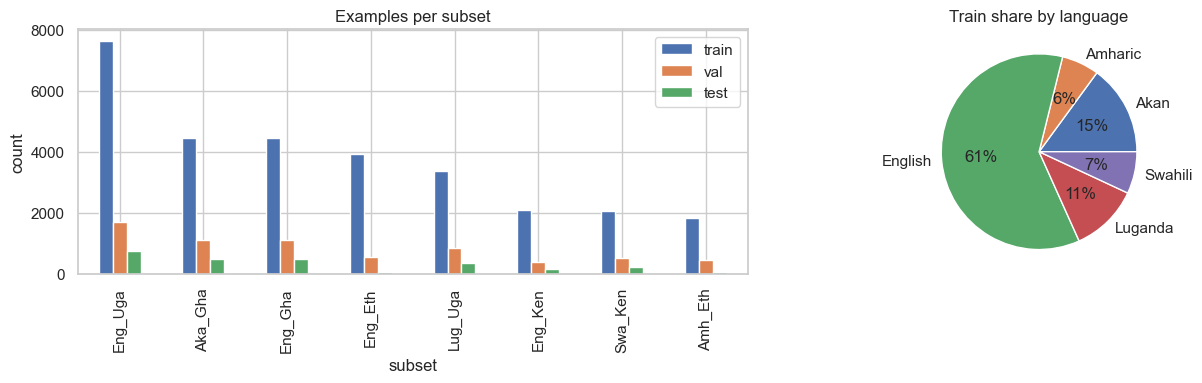

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
dist[['train','val','test']].plot(kind='bar', ax=ax[0])
ax[0].set_title('Examples per subset'); ax[0].set_ylabel('count')
dist.groupby('language')['train'].sum().plot(kind='pie', autopct='%1.0f%%', ax=ax[1])
ax[1].set_title('Train share by language'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

## 3. Text length analysis

Drives `max_source_len` / `max_target_len`. I measure both characters and
an approximate token count (whitespace); true subword counts are larger for
non-Latin scripts.

In [5]:
train['in_chars']  = train['input'].str.len()
train['out_chars'] = train['output'].astype(str).str.len()
train['in_words']  = train['input'].str.split().str.len()
train['out_words'] = train['output'].astype(str).str.split().str.len()
train[['in_chars','out_chars','in_words','out_words']].describe(percentiles=[.5,.9,.95,.99])

,in_chars,out_chars,in_words,out_words
count,29815.000000,29815.000000,29815.000000,29815.000000
mean,89.915143,492.851283,15.138588,76.217206
std,50.838964,382.517333,9.098043,58.851291
min,1.000000,6.000000,0.000000,1.000000
50%,78.000000,403.000000,13.000000,61.000000
90%,159.000000,1002.600000,27.000000,153.000000
95%,195.000000,1209.000000,34.000000,184.000000
99%,261.000000,1691.000000,49.000000,272.000000
max,520.000000,2956.000000,83.000000,482.000000


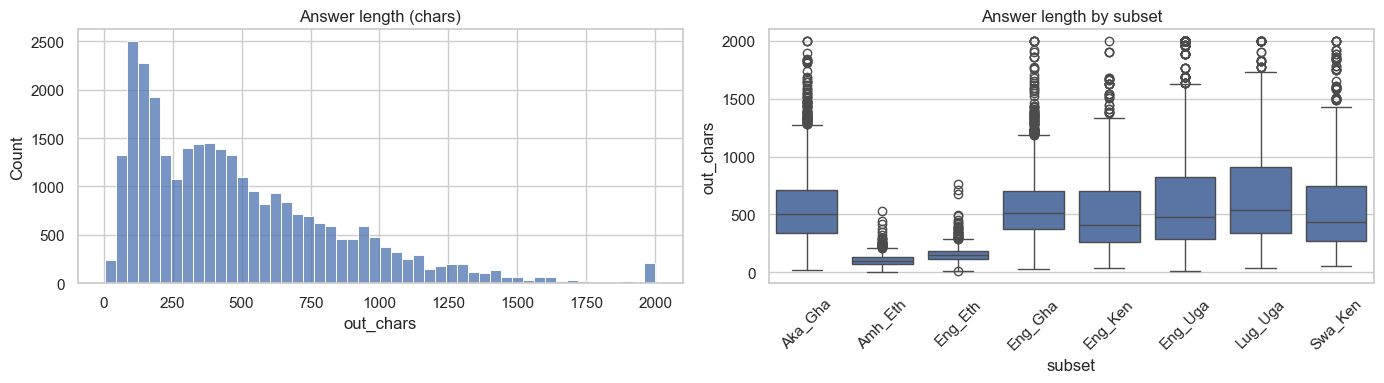

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(train['out_chars'].clip(upper=2000), bins=50, ax=ax[0])
ax[0].set_title('Answer length (chars)')
sns.boxplot(data=train, x='subset', y=train['out_chars'].clip(upper=2000), ax=ax[1])
ax[1].set_title('Answer length by subset'); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**Takeaway:** answers are long (median ~400 chars, 99th pct ~1700). A target
length of 320-384 subword tokens captures the bulk while keeping training on
8 GB feasible; the long tail is truncated.

## 4. Script & language sanity checks

Are 'English' subsets actually English? Do Amharic rows use Ethiopic script?
This validates that the subset label is a reliable language signal.

In [7]:
def script_profile(text):
    blocks = {}
    for ch in str(text):
        if ch.isspace() or not ch.isalpha():
            continue
        name = unicodedata.name(ch, '').split(' ')[0]
        blocks[name] = blocks.get(name, 0) + 1
    return blocks
amh = train[train.subset=='Amh_Eth'].iloc[0]['output']
print('Amharic sample scripts:', script_profile(amh))
aka = train[train.subset=='Aka_Gha'].iloc[0]['output']
print('Akan sample (note special letters ɛ ɔ):', repr(aka[:120]))

Amharic sample scripts: {'ETHIOPIC': 29, 'LATIN': 3}
Akan sample (note special letters ɛ ɔ): 'Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagy'


## 5. Duplicates, leakage & quality

In [8]:
print('dup questions in train:', train['input'].duplicated().sum())
print('dup (input,output) pairs:', train.duplicated(['input','output']).sum())
overlap = set(train['input']) & set(test['input'])
print('train/test question overlap:', len(overlap))
print('empty/near-empty answers (<5 chars):', (train['out_chars']<5).sum())

dup questions in train: 1469
dup (input,output) pairs: 276
train/test question overlap: 0
empty/near-empty answers (<5 chars): 0


## 6. Sample QA pairs per language

Qualitative read - note the instructional, list-like answer style the model
should imitate.

In [9]:
for s in ['Eng_Ken','Aka_Gha','Swa_Ken','Amh_Eth','Lug_Uga']:
    r = train[train.subset==s].iloc[0]
    print(f'\n=== {s} ({SUBSET_INFO[s][0]}) ===')
    print('Q:', r['input'][:160])
    print('A:', r['output'][:240])


=== Eng_Ken (English) ===
Q: How can society ensure that HIV patients are incorporated in it?
A: Incorporating HIV patients into society is essential to reduce stigma, promote inclusivity, and support their overall well-being. People living with HIV should have the same opportunities and rights as anyone else. Here are several ways to 

=== Aka_Gha (Akan) ===
Q: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa fi
A: Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya

=== Swa_Ken (Swahili) ===
Q: Je, PrEP inatoa ulinzi kweli, au imani katika ufanisi wake inachukuliwa kuwa hadithi?
A: PrEP (Pre-Exposure Prophylaxis) sio hadithi; ni mkakati wa kweli na madhubuti wa kuzuia virusi vya ukimwi. PrE

## 7. EDA summary and modeling decisions

- **Imbalance**: Eng_Uga >> Amh_Eth, so I report macro (per-subset) ROUGE, not only
  micro, and later add balanced sampling (Exp 12).
- **Long answers**: I set a target length of 320-384 tokens; long-answer subsets are
  truncated, a documented limitation.
- **Reliable language label**: the `subset` tag is a clean signal, so I inject it
  into the prompt (Exp 4).
- **Special orthography** (ɛ ɔ ŋ, Ethiopic): I keep cleaning conservative
  (Unicode-NFC + whitespace only), with no lowercasing or accent-stripping.
- **Low overlap / few dups**: little leakage, so honest generalization is required.